In [142]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.neural_network import MLPClassifier
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram
from sklearn.datasets import make_blobs
import numpy as np
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

In [81]:
#Imported saved dataframe from R
stroke_data = pd.read_csv("C:/Users/Marek/Documents/stroke_data.csv")

In [82]:
stroke_data

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,stroke_cat,hypertension_cat,heart_disease_cat
0,9046,Male,67,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1,Yes,No,Yes
1,31112,Male,80,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1,Yes,No,Yes
2,60182,Female,49,0,0,Yes,Private,Urban,171.23,34.4,smokes,1,Yes,No,No
3,1665,Female,79,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1,Yes,Yes,No
4,56669,Male,81,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1,Yes,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3420,68398,Male,82,1,0,Yes,Self-employed,Rural,71.97,28.3,never smoked,0,No,Yes,No
3421,45010,Female,57,0,0,Yes,Private,Rural,77.93,21.7,never smoked,0,No,No,No
3422,44873,Female,81,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0,No,No,No
3423,19723,Female,35,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0,No,No,No


In [68]:
#Used Neural Network for classification with using age, avg_glucose_level, bmi, hypertension, and heart_disease to predict stroke
X = stroke_data[["age", "avg_glucose_level", "bmi", "hypertension", "heart_disease"]]
y = stroke_data["stroke"]

num_col = ["age", "avg_glucose_level", "bmi"]
scaler = StandardScaler()
stroke_data[num_col] = scaler.fit_transform(stroke_data[num_col])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

mlp_classify = MLPClassifier()

params_options = {
    "hidden_layer_sizes": [[10,5,10,5,10], [3,3,3], [5,5,5], [5,5,5,5,5]],
    "activation": ["identity", "logistic", "tanh", "relu"],
    "max_iter": [100, 200, 500, 1000]
}

random_search = RandomizedSearchCV(mlp_classify, params_options, n_iter = 20, scoring="accuracy", cv=5, n_jobs= -1)
random_search.fit(X_train, y_train)

print("Best Hyperparameters:", random_search.best_params_)
print("Best Accuracy:", random_search.best_score_)

y_pred = random_search.predict(X_test)
print("Test Accuracy:", accuracy_score(y_pred, y_test))

Best Hyperparameters: {'max_iter': 100, 'hidden_layer_sizes': [5, 5, 5], 'activation': 'logistic'}
Best Accuracy: 0.9507724425887265
Test Accuracy: 0.9396887159533074


C:\Users\marek\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


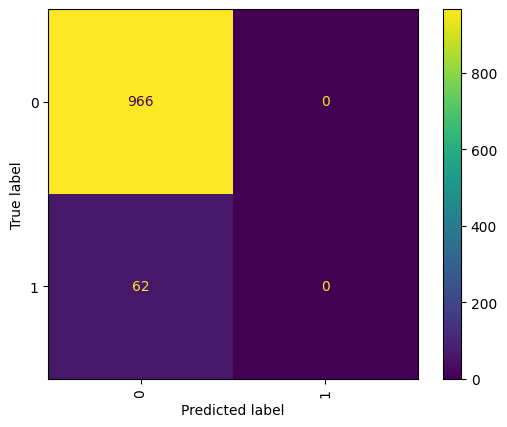

In [69]:
#Prints a confusion matrix of the classification neural network
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=random_search.best_estimator_.classes_)
disp.plot(xticks_rotation='vertical')

In [83]:
#This one hot encodes the 'ever_married' column to be able to use in classification then prints the dataframe
stroke_data = pd.get_dummies(stroke_data, columns=['ever_married'])
stroke_data

,id,gender,age,hypertension,heart_disease,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,stroke_cat,hypertension_cat,heart_disease_cat,ever_married_No,ever_married_Yes
0,9046,Male,67,0,1,Private,Urban,228.69,36.6,formerly smoked,1,Yes,No,Yes,False,True
1,31112,Male,80,0,1,Private,Rural,105.92,32.5,never smoked,1,Yes,No,Yes,False,True
2,60182,Female,49,0,0,Private,Urban,171.23,34.4,smokes,1,Yes,No,No,False,True
3,1665,Female,79,1,0,Self-employed,Rural,174.12,24.0,never smoked,1,Yes,Yes,No,False,True
4,56669,Male,81,0,0,Private,Urban,186.21,29.0,formerly smoked,1,Yes,No,No,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3420,68398,Male,82,1,0,Self-employed,Rural,71.97,28.3,never smoked,0,No,Yes,No,False,True
3421,45010,Female,57,0,0,Private,Rural,77.93,21.7,never smoked,0,No,No,No,False,True
3422,44873,Female,81,0,0,Self-employed,Urban,125.20,40.0,never smoked,0,No,No,No,False,True
3423,19723,Female,35,0,0,Self-employed,Rural,82.99,30.6,never smoked,0,No,No,No,False,True


In [84]:
# Sets bew variables for X which will be used as the features of the random forest classifier
X = stroke_data[["age", "avg_glucose_level", "bmi", "hypertension", "heart_disease","ever_married_Yes" ]]

In [85]:
#What variables contribute most to predicting stroke?
#This cell created a random forest classsifier whihc is a machine learning model. n_estimators creates 100 decision trees and random_state = 42
#ensures the results are reproducible
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X,y)           #Trains the prodel with X being preiction variables and y being the target
feature_importances = pd.DataFrame({             #This gives us an importance score for each feature
    'feature': X.columns,
    'importance': rf.feature_importances_
})

feature_importances = feature_importances.sort_values(by='importance', ascending=False)      #Creates a table which sorts the features from most important to least important


print(feature_importances)      #Prints the table

             feature  importance
1  avg_glucose_level    0.380712
2                bmi    0.311624
0                age    0.242293
3       hypertension    0.025873
4      heart_disease    0.022664
5   ever_married_Yes    0.016833


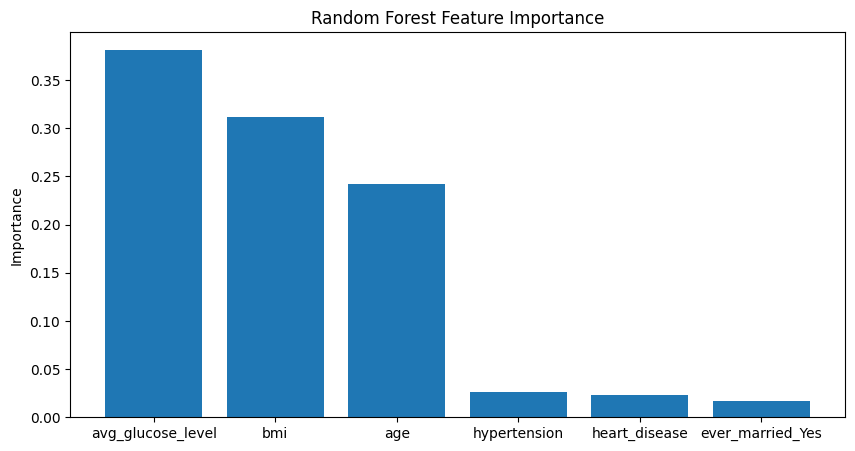

In [95]:
#Creates a bar plot of the random forest classifier results
plt.figure(figsize=(10,5))
plt.bar(feature_importances['feature'], feature_importances['importance'])
plt.ylabel('Importance')
plt.title('Random Forest Feature Importance')
plt.show()

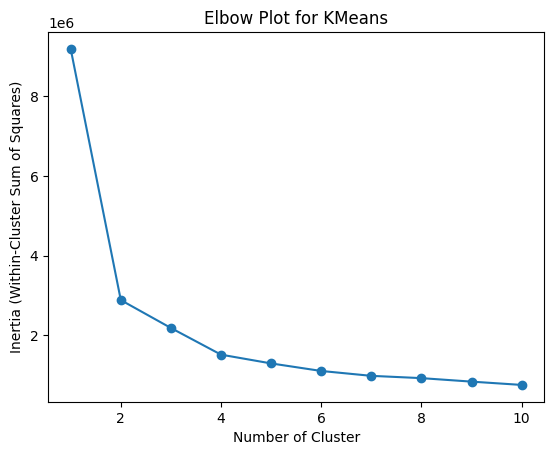

In [137]:
#Use KMeans to find # of clusters
inertia_values = []
for n_clusters in range(1, 11):
    kmeans = KMeans(n_clusters=n_clusters, n_init='auto')
    kmeans.fit(X)
    inertia_values.append(kmeans.inertia_)

#Plot the elbow plot to find # of clusters is 4
plt.plot(range(1,11), inertia_values, marker='o')
plt.xlabel('Number of Cluster')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.title('Elbow Plot for KMeans')
plt.show()

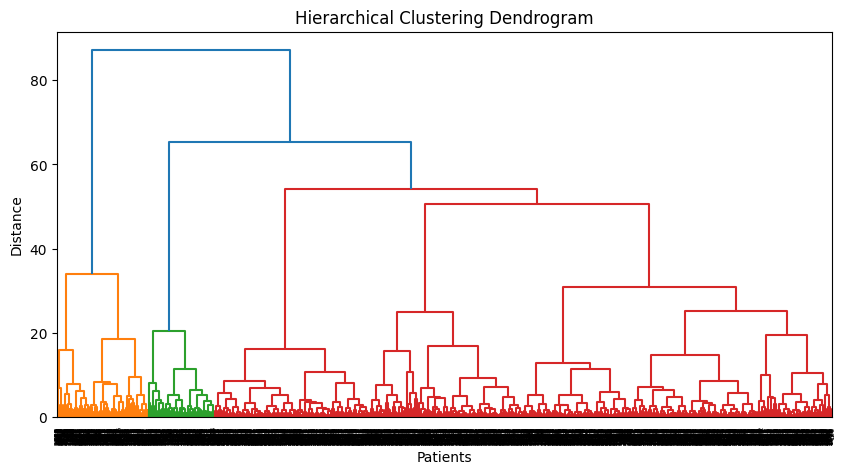

Stroke rate per cluster:
hier_cluster
1    0.140394
2    0.126280
3    0.001460
4    0.041646
Name: stroke, dtype: float64


In [138]:
#Picked the variables to cluster
X = stroke_data[["age", "avg_glucose_level", "bmi", "hypertension"]]

#Scales the variables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#This performs hierarchial clustering, the method merges clusters by minimizing the increase in within-cluster variance
Z = linkage(X_scaled, method='ward')

#Plots the dendogram
plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Patients")
plt.ylabel("Distance")
plt.show()

#Ensure the dendogram ends in 4 clusters based of the elbow plot
stroke_data['hier_cluster'] = fcluster(Z, 4, criterion='maxclust')

#Compares the stroke rate across the different cluters
stroke_rates = stroke_data.groupby('hier_cluster')['stroke'].mean()
print("Stroke rate per cluster:")
print(stroke_rates)